# Marker Heatmaps Across Diffusion Pseudotime

This notebook reproduces the marker heatmaps previously generated in the tubule-specific analysis folders, but now does so from the unified diffusion pseudotime object saved in `all_tubules_scanpy_dpt.h5ad`. The marker panels are carried over directly from the old proximal, ascending limb, distal, and total-nephron heatmaps.


The heatmaps no longer rebuild pseudospace separately for each cluster or segment-level object. Instead, each continuum is read from the saved Scanpy diffusion pseudotime coordinate in the lean combined AnnData file, binned along pseudotime, and displayed after restricting each gene to the central window containing 95% of its smoothed expression mass. This preserves the old marker structure while removing the need to recalculate trajectory coordinates for each downstream figure.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import sparse
from scipy.ndimage import gaussian_filter1d
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120

PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'data'
INPUT_PATH = DATA_DIR / 'all_tubules_scanpy_dpt.h5ad'
OUTPUT_DIR = DATA_DIR / 'heatmaps'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT_PATH)
if 'lognorm' in adata.layers:
    adata.X = adata.layers['lognorm'].copy()

REQUIRED_OBS_COLUMNS = [
    'sample',
    'species',
    'condition',
    'broad_tubule_marker_call',
    'pt_scanpy_dpt',
    'tal_scanpy_dpt',
    'dct_scanpy_dpt',
    'total_scanpy_dpt',
]
missing_obs = [col for col in REQUIRED_OBS_COLUMNS if col not in adata.obs.columns]
if missing_obs:
    raise KeyError(
        'all_tubules_scanpy_dpt.h5ad is missing required obs columns: '
        f'{missing_obs}. Regenerate this file from the final save cell in '
        'pseudospace_reconstruction.ipynb before running heatmaps.ipynb.'
    )

print(f'Loaded {INPUT_PATH.name}: {adata.n_obs:,} tubules x {adata.n_vars:,} genes')
print(f'Loaded obs columns: {list(adata.obs.columns)}')
print(f'Heatmaps will be saved to: {OUTPUT_DIR}')





KeyError: "all_tubules_scanpy_dpt.h5ad is missing required obs columns: ['pt_scanpy_dpt', 'tal_scanpy_dpt', 'dct_scanpy_dpt']. Regenerate this file from the final save cell in pseudospace_reconstruction.ipynb before running heatmaps.ipynb."

In [ ]:
PT_MARKER_GROUPS = {
    'PT-S1': [
        {'label': 'SLC5A2 / Slc5a2', 'candidates': ['SLC5A2', 'Slc5a2']},
        {'label': 'SLC5A12 / Slc5a12', 'candidates': ['SLC5A12', 'Slc5a12']},
    ],
    'PT-S2': [
        {'label': 'SLC22A8 / Slc22a8', 'candidates': ['SLC22A8', 'Slc22a8']},
        {'label': 'SLC22A6 / Slc22a6', 'candidates': ['SLC22A6', 'Slc22a6']},
        {'label': 'SLC13A3 / Slc13a3', 'candidates': ['SLC13A3', 'Slc13a3']},
        {'label': 'SLC22A2 / Slc22a2', 'candidates': ['SLC22A2', 'Slc22a2']},
        {'label': 'SLC34A1 / Slc34a1', 'candidates': ['SLC34A1', 'Slc34a1']},
    ],
    'PT-S3': [
        {'label': 'SLC7A13 / Slc7a13', 'candidates': ['SLC7A13', 'Slc7a13']},
        {'label': 'SLC5A8 / Slc5a8', 'candidates': ['SLC5A8', 'Slc5a8']},
        {'label': 'SLC38A3 / Slc38a3', 'candidates': ['SLC38A3', 'Slc38a3']},
        {'label': 'HAO2 / Hao2', 'candidates': ['HAO2', 'Hao2']},
        {'label': 'PCK1 / Pck1', 'candidates': ['PCK1', 'Pck1']},
        {'label': 'ACSM3 / Acsm3', 'candidates': ['ACSM3', 'Acsm3']},
    ],
}
PT_COLORS = {'PT-S1': '#4C9BD3', 'PT-S2': '#5B8E55', 'PT-S3': '#D6B48A'}

TAL_MARKER_GROUPS = {
    'mTAL / early TAL-like': [
        {'label': 'SLC12A1 / Slc12a1', 'candidates': ['SLC12A1', 'Slc12a1']},
        {'label': 'UMOD / Umod', 'candidates': ['UMOD', 'Umod']},
        {'label': 'KCNJ1 / Kcnj1', 'candidates': ['KCNJ1', 'Kcnj1']},
        {'label': 'BSND / Bsnd', 'candidates': ['BSND', 'Bsnd']},
        {'label': 'CLCNKB / Clcnkb', 'candidates': ['CLCNKB', 'Clcnkb']},
        {'label': 'ATP1A1 / Atp1a1', 'candidates': ['ATP1A1', 'Atp1a1']},
        {'label': 'ATP1B1 / Atp1b1', 'candidates': ['ATP1B1', 'Atp1b1']},
    ],
    'cTAL / late TAL-like': [
        {'label': 'CLDN10 / Cldn10', 'candidates': ['CLDN10', 'Cldn10']},
        {'label': 'CLDN16 / Cldn16', 'candidates': ['CLDN16', 'Cldn16']},
        {'label': 'CLDN19 / Cldn19', 'candidates': ['CLDN19', 'Cldn19']},
        {'label': 'CASR / Casr', 'candidates': ['CASR', 'Casr']},
        {'label': 'PTH1R / Pth1r', 'candidates': ['PTH1R', 'Pth1r']},
        {'label': 'VDR / Vdr', 'candidates': ['VDR', 'Vdr']},
    ],
    'Macula densa / TAL-DCT boundary': [
        {'label': 'NOS1 / Nos1', 'candidates': ['NOS1', 'Nos1']},
        {'label': 'PTGS2 / Ptgs2', 'candidates': ['PTGS2', 'Ptgs2']},
    ],
}
TAL_COLORS = {'mTAL / early TAL-like': '#4C78A8', 'cTAL / late TAL-like': '#F58518', 'Macula densa / TAL-DCT boundary': '#E45756'}

DCT_MARKER_GROUPS = {
    'DCT1': [
        {'label': 'SLC12A3 / Slc12a3', 'candidates': ['SLC12A3', 'Slc12a3']},
        {'label': 'PVALB / Pvalb', 'candidates': ['PVALB', 'Pvalb']},
    ],
    'DCT2': [
        {'label': 'CALB1 / Calb1', 'candidates': ['CALB1', 'Calb1']},
        {'label': 'HSD11B2 / Hsd11b2', 'candidates': ['HSD11B2', 'Hsd11b2']},
        {'label': 'SCNN1G / Scnn1g', 'candidates': ['SCNN1G', 'Scnn1g']},
    ],
}
DCT_COLORS = {'DCT1': '#4C78A8', 'DCT2': '#F58518'}

TOTAL_NEPHRON_MARKERS = [
    {'label': 'Slc5a2 (PT-S1)', 'candidates': ['SLC5A2', 'Slc5a2']},
    {'label': 'Slc22a6 (PT-S2)', 'candidates': ['SLC22A6', 'Slc22a6']},
    {'label': 'Lrp2 (PT / pan-PT)', 'candidates': ['LRP2', 'Lrp2']},
    {'label': 'Slc9a3 (PT)', 'candidates': ['SLC9A3', 'Slc9a3']},
    {'label': 'Slc34a1 (PT / phosphate transport)', 'candidates': ['SLC34A1', 'Slc34a1']},
    {'label': 'Aqp1 (DTL / PT-DTL-associated, depending subset)', 'candidates': ['AQP1', 'Aqp1']},
    {'label': 'Clcnka (ATL)', 'candidates': ['CLCNKA', 'Clcnka']},
    {'label': 'Slc12a1 (TAL)', 'candidates': ['SLC12A1', 'Slc12a1']},
    {'label': 'Umod (TAL)', 'candidates': ['UMOD', 'Umod']},
    {'label': 'Pvalb (DCT1)', 'candidates': ['PVALB', 'Pvalb']},
    {'label': 'Slc12a3 (DCT)', 'candidates': ['SLC12A3', 'Slc12a3']},
    {'label': 'Calb1 (DCT2/CNT)', 'candidates': ['CALB1', 'Calb1']},
    {'label': 'Aqp2 (CCD / principal cell)', 'candidates': ['AQP2', 'Aqp2']},
    {'label': 'Scnn1g (CNT/CD principal cell)', 'candidates': ['SCNN1G', 'Scnn1g']},
    {'label': 'Slc4a1 (OMCD / intercalated cell)', 'candidates': ['SLC4A1', 'Slc4a1']},
    {'label': 'Slc26a4 (OMCD / pendrin+ intercalated cell)', 'candidates': ['SLC26A4', 'Slc26a4']},
    {'label': 'Atp6v1g3 (CD intercalated cell)', 'candidates': ['ATP6V1G3', 'Atp6v1g3']},
]

def matrix_to_dense(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)

def resolve_gene_aliases(adata_obj, marker_groups):
    var_names = pd.Index(adata_obj.var_names.astype(str))
    lookup = {name.upper(): name for name in var_names}
    alias_columns = [col for col in ['gene_symbol', 'gene_symbols', 'symbol', 'gene_name', 'feature_name', 'features'] if col in adata_obj.var.columns]
    for col in alias_columns:
        for idx_name, alias in zip(var_names, adata_obj.var[col].astype(str)):
            alias_upper = alias.upper()
            if alias_upper and alias_upper != 'NAN' and alias_upper not in lookup:
                lookup[alias_upper] = idx_name
    resolved = {}
    missing = []
    for group_name, markers in marker_groups.items():
        for marker in markers:
            match = None
            for candidate in marker['candidates']:
                match = lookup.get(candidate.upper())
                if match is not None:
                    break
            if match is None:
                missing.append(marker['label'])
            else:
                resolved[marker['label']] = match
    return resolved, missing

def resolve_marker_list(adata_obj, markers):
    resolved, missing = resolve_gene_aliases(adata_obj, {'all': markers})
    ordered = [marker['label'] for marker in markers if marker['label'] in resolved]
    return ordered, resolved, missing

def normalize_01(values):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    out = np.full(values.shape, np.nan, dtype=float)
    if finite.sum() == 0:
        return out
    lo = np.nanmin(values[finite])
    hi = np.nanmax(values[finite])
    out[finite] = (values[finite] - lo) / max(hi - lo, 1e-8)
    return out

def central_mass_mask(row, mass_fraction=0.95):
    weights = np.asarray(row, dtype=float).copy()
    weights[~np.isfinite(weights)] = 0
    weights = np.maximum(weights, 0)
    if weights.sum() <= 0:
        return np.zeros_like(weights, dtype=bool)
    cdf = np.cumsum(weights) / weights.sum()
    lower_q = (1 - mass_fraction) / 2
    upper_q = 1 - lower_q
    left = int(np.searchsorted(cdf, lower_q, side='left'))
    right = int(np.searchsorted(cdf, upper_q, side='left'))
    mask = np.zeros_like(weights, dtype=bool)
    mask[left:right + 1] = True
    return mask


PSEUDOTIME_COLUMNS = {
    'PT': 'pt_scanpy_dpt',
    'TAL': 'tal_scanpy_dpt',
    'DCT': 'dct_scanpy_dpt',
    'TOTAL': 'total_scanpy_dpt',
}

def resolve_pseudotime_column(adata_obj, continuum):
    col = PSEUDOTIME_COLUMNS[continuum]
    if col not in adata_obj.obs.columns:
        raise KeyError(
            f"Missing required pseudotime column for {continuum}: {col}. "
            'This notebook only uses all_tubules_scanpy_dpt.h5ad; regenerate that file from '
            'the final save cell in pseudospace_reconstruction.ipynb.'
        )
    return col

def build_species_heatmaps(adata_obj, pseudotime_col, gene_order, resolved_map, subset_mask=None, n_bins=120, smooth_sigma=1, expression_layer='lognorm'):
    if subset_mask is None:
        subset_mask = np.ones(adata_obj.n_obs, dtype=bool)
    else:
        subset_mask = np.asarray(subset_mask, dtype=bool)
    valid_mask = subset_mask & adata_obj.obs[pseudotime_col].notna().to_numpy()
    adata_plot = adata_obj[valid_mask].copy()
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    species_order = [('mouse', 'Mouse'), ('human', 'Human')]
    gene_idx = [adata_plot.var_names.get_loc(resolved_map[label]) for label in gene_order]
    heatmaps_raw = {}
    heatmaps_z = {}
    cell_counts = {}
    for species_key, species_label in species_order:
        species_mask = adata_plot.obs['species'].astype(str).str.lower().str.contains(species_key, na=False).to_numpy()
        if species_mask.sum() == 0:
            raise ValueError(f'No {species_label.lower()} tubules found for {pseudotime_col}')
        adata_species = adata_plot[species_mask].copy()
        pos = normalize_01(adata_species.obs[pseudotime_col].to_numpy(dtype=float))
        sort_idx = np.argsort(pos)
        pos = pos[sort_idx]
        X_obj = adata_species.layers[expression_layer] if expression_layer in adata_species.layers else adata_species.X
        expr = matrix_to_dense(X_obj[:, gene_idx])[sort_idx].T
        bin_ids = np.digitize(pos, bins) - 1
        bin_ids = np.clip(bin_ids, 0, n_bins - 1)
        heatmap = np.full((len(gene_order), n_bins), np.nan)
        for bin_id in range(n_bins):
            mask = bin_ids == bin_id
            if mask.sum() > 0:
                heatmap[:, bin_id] = expr[:, mask].mean(axis=1)
        for gene_i in range(heatmap.shape[0]):
            valid = np.isfinite(heatmap[gene_i])
            if valid.sum() == 1:
                heatmap[gene_i, :] = heatmap[gene_i, valid][0]
            elif valid.sum() > 1:
                heatmap[gene_i, :] = np.interp(bin_centers, bin_centers[valid], heatmap[gene_i, valid])
        if smooth_sigma > 0:
            heatmap = gaussian_filter1d(heatmap, sigma=smooth_sigma, axis=1)
        gene_mean = heatmap.mean(axis=1, keepdims=True)
        gene_std = heatmap.std(axis=1, keepdims=True)
        gene_std[gene_std == 0] = 1
        heatmaps_raw[species_key] = heatmap
        heatmaps_z[species_key] = (heatmap - gene_mean) / gene_std
        cell_counts[species_key] = int(species_mask.sum())
    pooled_raw = np.nanmean(np.stack([heatmaps_raw['mouse'], heatmaps_raw['human']]), axis=0)
    keep_masks = np.vstack([central_mass_mask(row, mass_fraction=0.95) for row in pooled_raw])
    return adata_plot, bin_centers, heatmaps_raw, heatmaps_z, keep_masks, cell_counts

def plot_segment_heatmap(adata_obj, marker_groups, group_order, segment_colors, pseudotime_col, subset_mask, title, output_name, n_bins=120, smooth_sigma=1, z_clip=2):
    resolved_map, missing = resolve_gene_aliases(adata_obj, marker_groups)
    available_groups = {group: [m['label'] for m in marker_groups[group] if m['label'] in resolved_map] for group in group_order}
    available_groups = {k: v for k, v in available_groups.items() if v}
    if not available_groups:
        raise ValueError(f'No marker genes were resolved for {title}')
    gene_order = [label for group in group_order if group in available_groups for label in available_groups[group]]
    adata_plot, bin_centers, heatmaps_raw, heatmaps_z, keep_masks, cell_counts = build_species_heatmaps(
        adata_obj,
        pseudotime_col=pseudotime_col,
        gene_order=gene_order,
        resolved_map=resolved_map,
        subset_mask=subset_mask,
        n_bins=n_bins,
        smooth_sigma=smooth_sigma,
    )
    heatmap_gene_z = np.nanmean(np.stack([heatmaps_z['mouse'], heatmaps_z['human']]), axis=0)
    module_names = [group for group in group_order if group in available_groups]
    gene_pos = {gene: i for i, gene in enumerate(gene_order)}
    module_scores = np.vstack([
        heatmap_gene_z[[gene_pos[gene] for gene in available_groups[group]]].mean(axis=0)
        for group in module_names
    ])
    dominant_module = np.argmax(module_scores, axis=0)
    heatmap_z = np.vstack([
        np.where(keep_masks[gene_i], np.clip(heatmaps_z[species_key][gene_i], -z_clip, z_clip), np.nan)
        for gene_i in range(len(gene_order))
        for species_key in ['mouse', 'human']
    ])
    cmap = plt.get_cmap('bwr').copy()
    cmap.set_bad(color='#f0f0f0')
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 0.25, 8], hspace=0.08)
    ax_top = fig.add_subplot(gs[0])
    ax_strip = fig.add_subplot(gs[1], sharex=ax_top)
    ax_heat = fig.add_subplot(gs[2], sharex=ax_top)
    for module_idx, module_name in enumerate(module_names):
        ax_top.plot(bin_centers, module_scores[module_idx], color=segment_colors[module_name], linewidth=2.5, label=module_name)
    ax_top.set_xlim(0, 1)
    ax_top.set_ylabel('Module score')
    ax_top.set_xticks([])
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.legend(loc='upper right', frameon=False, ncol=max(1, len(module_names)))
    ax_strip.imshow(
        dominant_module[np.newaxis, :],
        aspect='auto',
        cmap=ListedColormap([segment_colors[name] for name in module_names]),
        interpolation='nearest',
        extent=[0, 1, 0, 1],
    )
    ax_strip.set_yticks([])
    ax_strip.set_xticks([])
    for spine in ax_strip.spines.values():
        spine.set_visible(False)
    im = ax_heat.imshow(
        heatmap_z,
        aspect='auto',
        cmap=cmap,
        vmin=-z_clip,
        vmax=z_clip,
        interpolation='nearest',
        extent=[0, 1, len(gene_order) - 0.25, -0.25],
    )
    ax_heat.set_xlabel(f'{pseudotime_col} (Scanpy DPT)')
    ax_heat.set_xticks(np.linspace(0, 1, 6))
    ax_heat.set_xticklabels([f'{x:.1f}' for x in np.linspace(0, 1, 6)])
    ax_heat.set_yticks(np.arange(len(gene_order)) + 0.25)
    ax_heat.set_yticklabels(gene_order, fontsize=10)
    ax_heat.yaxis.tick_right()
    ax_heat.tick_params(axis='y', length=0)
    for boundary in np.arange(0.75, len(gene_order) - 0.25, 1):
        ax_heat.axhline(boundary, color='black', linewidth=0.7)
    ax_heat.text(
        1.01,
        1.01,
        'Top half: Mouse\nBottom half: Human',
        transform=ax_heat.transAxes,
        ha='left',
        va='bottom',
        fontsize=10,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 0.8},
    )
    offset = 0
    for module_name in module_names:
        genes = available_groups[module_name]
        center = offset + (len(genes) - 1) / 2 + 0.25
        ax_heat.text(-0.02, center, module_name, transform=ax_heat.get_yaxis_transform(), ha='right', va='center', fontsize=11, fontweight='bold', color=segment_colors[module_name])
        offset += len(genes)
        if offset < len(gene_order):
            ax_heat.axhline(offset - 0.25, color='black', linewidth=1.0)
    fig.subplots_adjust(right=0.86)
    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.12)
    cbar.set_label('Per-gene/species z-score')
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0.04, 0, 0.84, 0.96])
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()
    return {
        'n_cells': adata_plot.n_obs,
        'genes_used': gene_order,
        'missing_markers': missing,
        'module_names': module_names,
        'cell_counts': cell_counts,
        'output_path': str((OUTPUT_DIR / output_name).relative_to(PROJECT_DIR)),
    }

def plot_total_heatmap(adata_obj, markers, pseudotime_col='total_scanpy_dpt', output_name='total_nephron_marker_heatmap.png', n_bins=120, smooth_sigma=1, z_clip=3):
    gene_order, resolved_map, missing = resolve_marker_list(adata_obj, markers)
    if not gene_order:
        raise ValueError('No total nephron markers were resolved')
    adata_plot, bin_centers, heatmaps_raw, heatmaps_z, keep_masks, cell_counts = build_species_heatmaps(
        adata_obj,
        pseudotime_col=pseudotime_col,
        gene_order=gene_order,
        resolved_map=resolved_map,
        subset_mask=None,
        n_bins=n_bins,
        smooth_sigma=smooth_sigma,
    )
    heatmap_z = np.vstack([
        np.where(keep_masks[gene_i], np.clip(heatmaps_z[species_key][gene_i], -z_clip, z_clip), np.nan)
        for gene_i in range(len(gene_order))
        for species_key in ['mouse', 'human']
    ])
    cmap = plt.get_cmap('bwr').copy()
    cmap.set_bad(color='#f0f0f0')
    fig_height = max(7, 0.36 * len(gene_order) + 2)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    im = ax.imshow(
        heatmap_z,
        aspect='auto',
        cmap=cmap,
        vmin=-z_clip,
        vmax=z_clip,
        interpolation='nearest',
        extent=[0, 1, len(gene_order) - 0.25, -0.25],
    )
    ax.set_xlabel('total_scanpy_dpt (Scanpy DPT)')
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f'{x:.1f}' for x in np.linspace(0, 1, 6)])
    ax.set_yticks(np.arange(len(gene_order)) + 0.25)
    ax.set_yticklabels(gene_order, fontsize=11, fontstyle='italic')
    ax.tick_params(axis='y', length=0)
    for boundary in np.arange(0.75, len(gene_order) - 0.25, 1):
        ax.axhline(boundary, color='black', linewidth=0.7)
    ax.text(
        1.01,
        1.01,
        'Top half: Mouse\nBottom half: Human',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=10,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 0.8},
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Per-gene/species z-score')
    ax.set_title(
        f'Total nephron marker expression across diffusion pseudotime '
        f'(mouse n={cell_counts["mouse"]:,}, human n={cell_counts["human"]:,})',
        fontsize=14,
        fontweight='bold',
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()
    return {
        'n_cells': adata_plot.n_obs,
        'genes_used': gene_order,
        'missing_markers': missing,
        'cell_counts': cell_counts,
        'output_path': str((OUTPUT_DIR / output_name).relative_to(PROJECT_DIR)),
    }





The proximal, TAL, and distal heatmaps keep the module-score line plot and module-strip layout used in the old notebooks. The total-nephron heatmap keeps the simpler whole-axis display from the original total-nephron notebook, now aligned to the saved all-tubules diffusion pseudotime coordinate from the lean combined DPT file.


/tmp/ipykernel_1841191/592594044.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0, 0.84, 0.96])


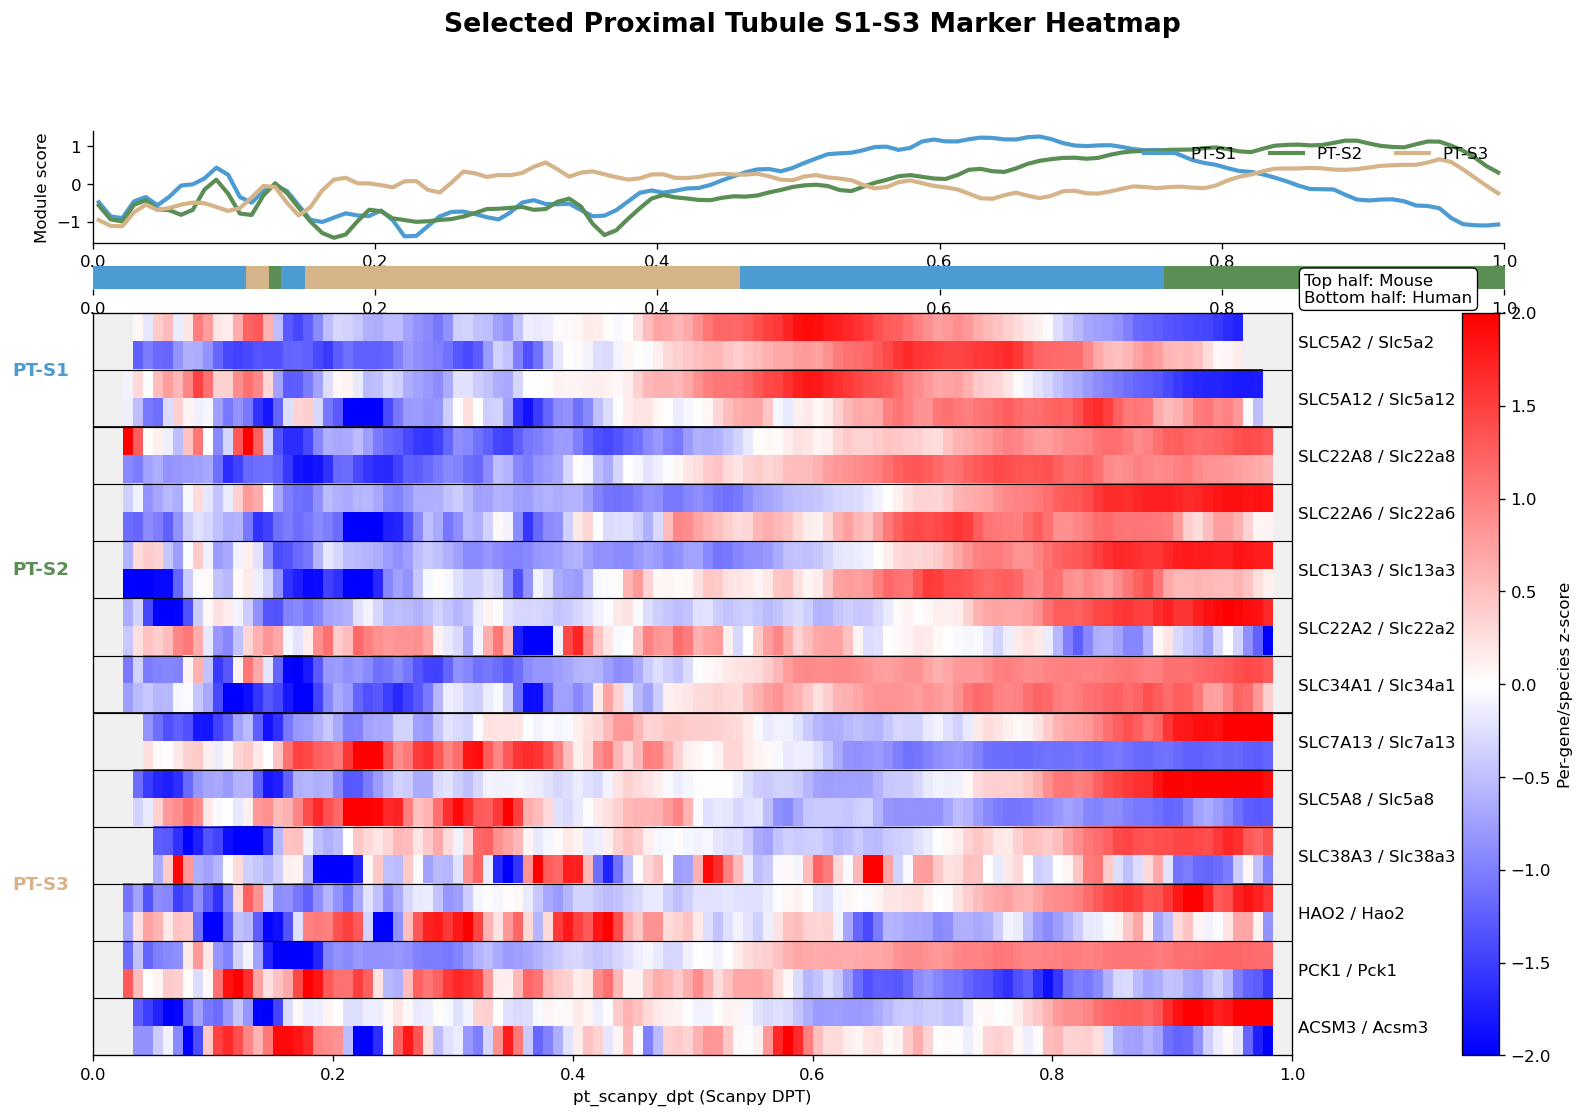

/tmp/ipykernel_1841191/592594044.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0, 0.84, 0.96])


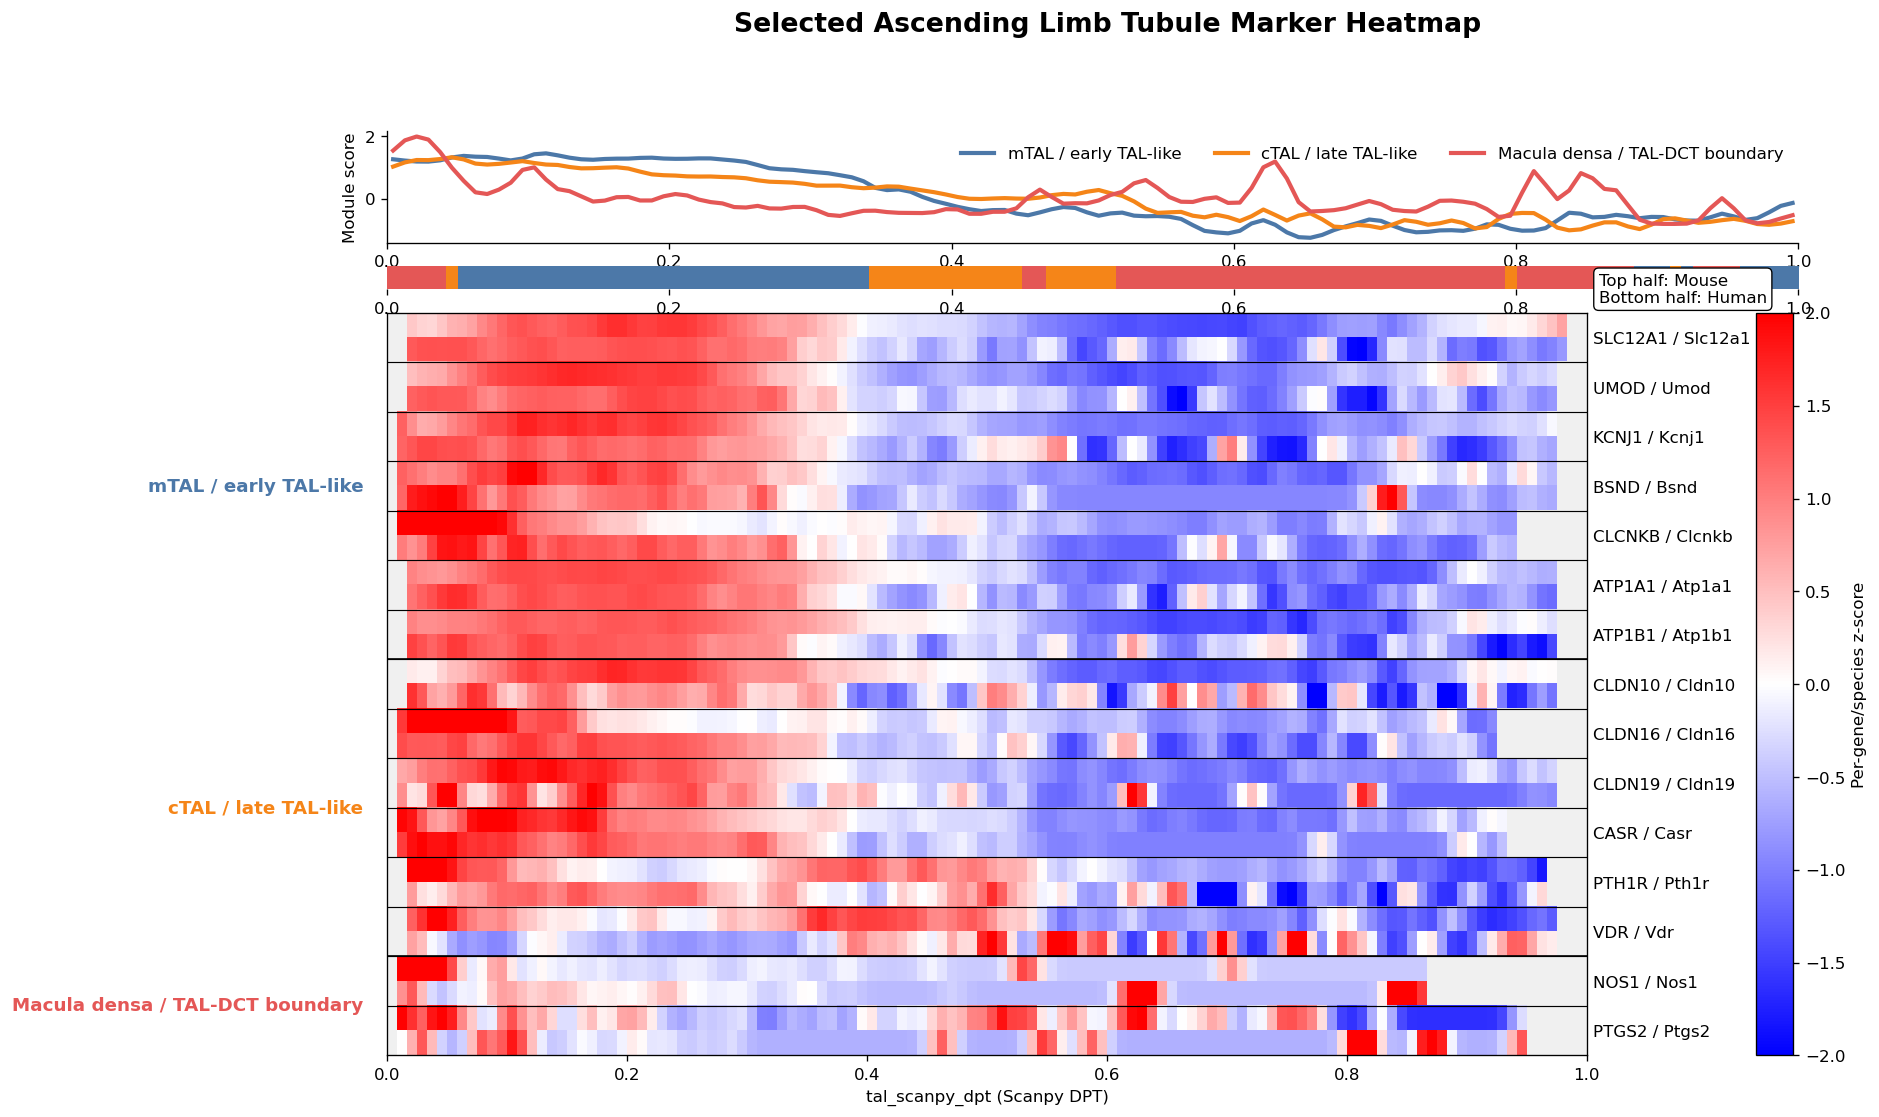

/tmp/ipykernel_1841191/592594044.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0, 0.84, 0.96])


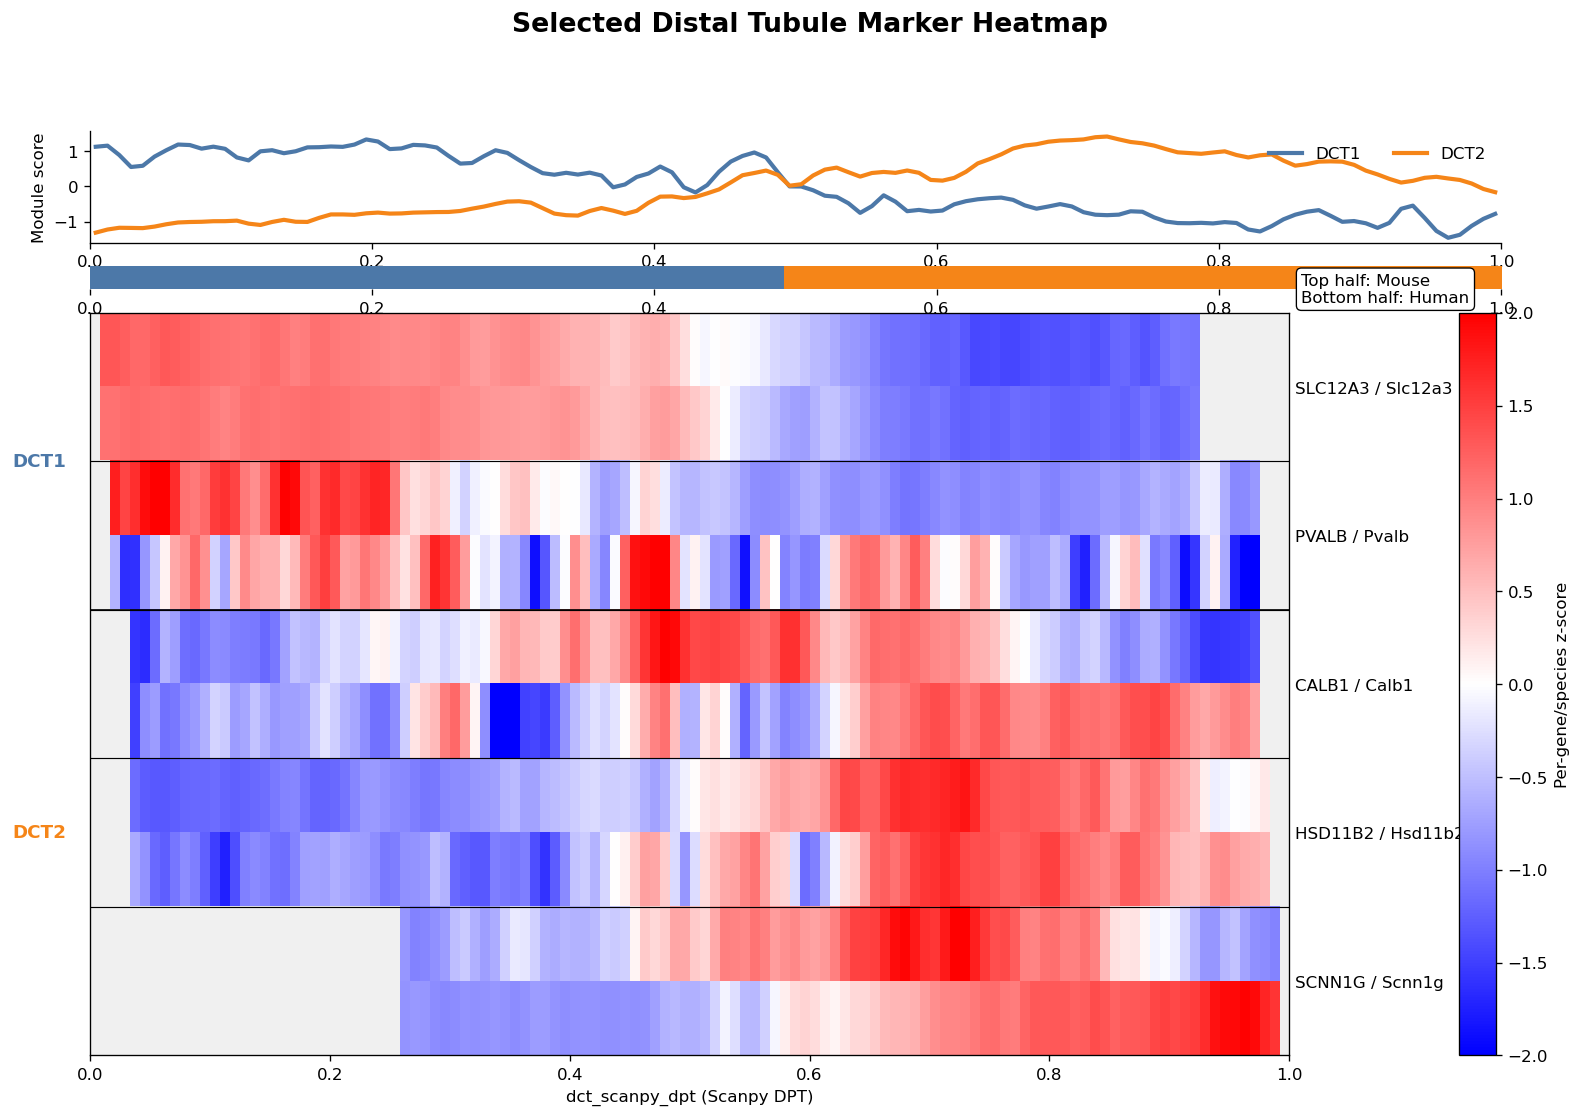

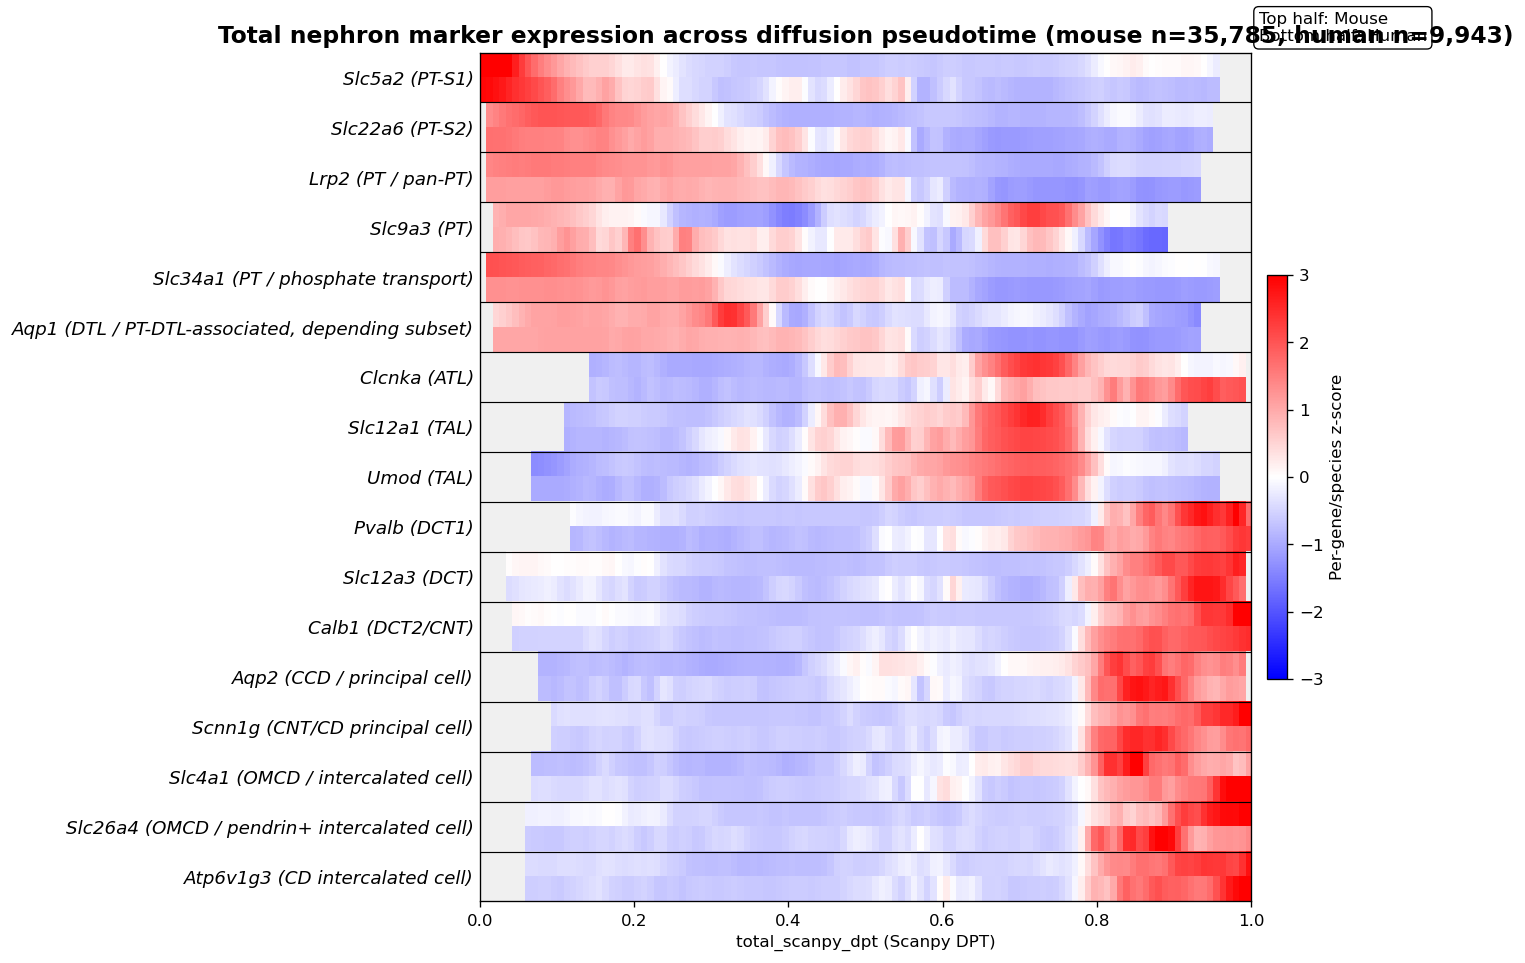

,n_cells,output_path
PT,19999,data/heatmaps/selected_pt_marker_heatmap.png
TAL,16183,data/heatmaps/selected_tal_marker_heatmap.png
DCT,4705,data/heatmaps/selected_dct_marker_heatmap.png
TOTAL,45728,data/heatmaps/total_nephron_marker_heatmap.png


,n_cells,genes_used,missing_markers,module_names,cell_counts,output_path
PT,19999,"[SLC5A2 / Slc5a2, SLC5A12 / Slc5a12, SLC22A8 /...",[],"[PT-S1, PT-S2, PT-S3]","{'mouse': 13585, 'human': 6414}",data/heatmaps/selected_pt_marker_heatmap.png
TAL,16183,"[SLC12A1 / Slc12a1, UMOD / Umod, KCNJ1 / Kcnj1...",[],"[mTAL / early TAL-like, cTAL / late TAL-like, ...","{'mouse': 14502, 'human': 1681}",data/heatmaps/selected_tal_marker_heatmap.png
DCT,4705,"[SLC12A3 / Slc12a3, PVALB / Pvalb, CALB1 / Cal...",[],"[DCT1, DCT2]","{'mouse': 3233, 'human': 1472}",data/heatmaps/selected_dct_marker_heatmap.png
TOTAL,45728,"[Slc5a2 (PT-S1), Slc22a6 (PT-S2), Lrp2 (PT / p...",[],NaN,"{'mouse': 35785, 'human': 9943}",data/heatmaps/total_nephron_marker_heatmap.png


In [ ]:
results = {}

pt_col = resolve_pseudotime_column(adata, 'PT')
results['PT'] = plot_segment_heatmap(
    adata,
    marker_groups=PT_MARKER_GROUPS,
    group_order=['PT-S1', 'PT-S2', 'PT-S3'],
    segment_colors=PT_COLORS,
    pseudotime_col=pt_col,
    subset_mask=adata.obs['broad_tubule_marker_call'].astype(str).eq('PT').to_numpy(),
    title='Selected Proximal Tubule S1-S3 Marker Heatmap',
    output_name='selected_pt_marker_heatmap.png',
)

tal_col = resolve_pseudotime_column(adata, 'TAL')
results['TAL'] = plot_segment_heatmap(
    adata,
    marker_groups=TAL_MARKER_GROUPS,
    group_order=['mTAL / early TAL-like', 'cTAL / late TAL-like', 'Macula densa / TAL-DCT boundary'],
    segment_colors=TAL_COLORS,
    pseudotime_col=tal_col,
    subset_mask=adata.obs['broad_tubule_marker_call'].astype(str).eq('TAL').to_numpy(),
    title='Selected Ascending Limb Tubule Marker Heatmap',
    output_name='selected_tal_marker_heatmap.png',
)

dct_col = resolve_pseudotime_column(adata, 'DCT')
results['DCT'] = plot_segment_heatmap(
    adata,
    marker_groups=DCT_MARKER_GROUPS,
    group_order=['DCT1', 'DCT2'],
    segment_colors=DCT_COLORS,
    pseudotime_col=dct_col,
    subset_mask=adata.obs['broad_tubule_marker_call'].astype(str).eq('DCT').to_numpy(),
    title='Selected Distal Tubule Marker Heatmap',
    output_name='selected_dct_marker_heatmap.png',
)

total_col = resolve_pseudotime_column(adata, 'TOTAL')
results['TOTAL'] = plot_total_heatmap(
    adata,
    markers=TOTAL_NEPHRON_MARKERS,
    pseudotime_col=total_col,
    output_name='total_nephron_marker_heatmap.png',
)

summary = pd.DataFrame(results).T
display(summary[['n_cells', 'output_path']])
summary

